# Laboratorio 5: Clasificación de tweets usando minería de texto

**Universidad del Valle de Guatemala — Facultad de Ingeniería — Departamento de Ciencias de la Computación**
**CC3084 — Data Science | Semestre II — 2026**
**Informe de avance — Fecha de entrega del avance: 27 de agosto de 2026, 17:20**

---

## 1. Introducción

Este notebook documenta el avance del Laboratorio 5, cuyo objetivo final es construir un modelo de clasificación que determine si un tweet se refiere a un **desastre real** (`target = 1`) o no (`target = 0`). Se utiliza el dataset *Natural Language Processing with Disaster Tweets* de Kaggle.

En esta primera entrega se presentan:

1. la descripción de los datos,
2. el preprocesamiento de texto realizado,
3. el análisis de unigramas y bigramas, y
4. la descripción de un modelo preliminar de clasificación.

> Todo el código es reproducible: basta ejecutar las celdas en orden. Las figuras se guardan en la carpeta `figures/` y corresponden a las figuras numeradas del informe.
>
> **Librerías necesarias:** `pandas`, `scikit-learn` (CountVectorizer, TfidfVectorizer, LogisticRegression, MultinomialNB, train_test_split, métricas), `nltk` (stopwords), `wordcloud`, `matplotlib` y `seaborn`. Si no están instaladas: `pip install pandas scikit-learn nltk wordcloud matplotlib seaborn`.

## 2. Descripción del dataset (Ejercicios 1 y 2 — Descarga y carga de datos)

### 2.1 Descarga (Ejercicio 1)

El archivo `train.csv` se descargó de la competencia de Kaggle [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started) y se guardó en la carpeta `data/`.

### 2.2 Carga y exploración (Ejercicio 2)

El archivo `train.csv` contiene **7 613 tweets** con las siguientes columnas:

- `id`: identificador del tweet.
- `keyword`: palabra clave del tweet (puede estar vacía).
- `location`: ubicación de origen (puede estar vacía).
- `text`: texto del tweet.
- `target`: 1 = desastre real, 0 = no desastre.

A continuación se carga el archivo con `pandas` y se hace una primera exploración (tipos de datos, nulos, distribución del target, keywords, locations, longitud y duplicados).

In [1]:
import pandas as pd

# ---- Carga del dataset ----
df = pd.read_csv("data/train.csv")

print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

print("\nPrimeras filas:")
print(df.head())

print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nPorcentaje de nulos:")
print((df.isnull().sum() / len(df) * 100).round(2))

print("\nDistribucion de la variable objetivo (target):")
print(df['target'].value_counts())
print((df['target'].value_counts(normalize=True) * 100).round(2))

print("\nNumero de keywords distintos:", df['keyword'].nunique())
print("Numero de locations distintas:", df['location'].nunique())

print("\nLongitud de texto (caracteres):")
df['text_len'] = df['text'].str.len()
print(df['text_len'].describe())

print("\nLongitud de texto (palabras):")
df['word_count'] = df['text'].str.split().str.len()
print(df['word_count'].describe())

# Duplicados
print("\nFilas duplicadas (por texto):", df.duplicated(subset=['text']).sum())

df.to_csv("data/train_explored.csv", index=False)

Dimensiones del dataset: (7613, 5)

Tipos de datos:
id           int64
keyword     object
location    object
text        object
target       int64
dtype: object

Primeras filas:
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  

Valores nulos por columna:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Porcentaje de nulos:
id           0.00
keyword      0.80
location    33.27
text         0.00
target       0.00
dtype: float64

Distribucion de la variable objet

**Hallazgos de la exploración (Tabla 1 del informe — resumen de valores nulos por variable):**

| Variable | Nulos | % Nulos | Observación |
|---|---|---|---|
| `keyword` | 61 | 0.80 % | 221 valores distintos; se puede imputar o usar como feature adicional |
| `location` | 2 533 | 33.27 % | 3 341 valores distintos, muy ruidosa (texto libre); requiere limpieza fuerte si se usa |
| `text` | 0 | 0.00 % | Sin valores nulos |
| `target` | 0 | 0.00 % | Variable objetivo, sin nulos |

**Distribución de la variable objetivo (Figura 1 del informe).**

La distribución muestra un **leve desbalance**: 4 342 tweets (57.0 %) no corresponden a un desastre real y 3 271 (43.0 %) sí. No es un desbalance severo, por lo que no se considera necesario aplicar técnicas de balanceo (SMOTE, undersampling) por ahora, aunque se evaluará el desempeño por clase con precision/recall en lugar de depender únicamente del accuracy.

Se identificaron además **92 tweets duplicados exactos** (mismo texto y mismo target), los cuales serán eliminados en el preprocesamiento para evitar sesgo en el conteo de frecuencias y en el entrenamiento del modelo. La longitud promedio de un tweet es de aproximadamente **101 caracteres y 15 palabras**, consistente con el límite histórico de Twitter de 140 caracteres.

## 3. Limpieza y preprocesamiento de datos (Ejercicio 3)

Se aplicó una función de limpieza (`clean_text`) en Python usando expresiones regulares y la librería NLTK. Los paquetes utilizados fueron: `pandas` para el manejo de datos, `re` para las expresiones regulares y `nltk.corpus.stopwords` para la eliminación de palabras vacías en inglés. Las tareas realizadas, en orden, fueron:

1. **Corrección de "mojibake"**: el texto original de Twitter contenía secuencias como `\x89ÛÒ` producto de una mala codificación de caracteres especiales (comillas curvas, elipsis). Se eliminaron los caracteres no-ASCII, ya que inicialmente aparecían como palabras "fantasma" (ej. `û_`) contaminando el top de frecuencias.
2. **Conversión de todo el texto a minúsculas**, para que `Fire` y `fire` se traten como el mismo token.
3. **Eliminación de URLs** (`http`, `https`, `www`) mediante expresiones regulares, ya que no aportan información semántica.
4. **Eliminación de menciones** (`@usuario`).
5. **Eliminación del símbolo `#`** de los hashtags, pero **conservando la palabra** (ej. `#earthquake` → `earthquake`), ya que suele contener información temática relevante.
6. **Eliminación de emojis/emoticones** mediante rangos Unicode.
7. **Eliminación de entidades HTML** (ej. `&amp;`).
8. **Eliminación de signos de puntuación** y guiones bajos residuales de la limpieza de mojibake.
9. **Eliminación de números**, con una excepción deliberada: se conserva el token `911`, porque en este dominio (clasificación de desastres) suele ser una señal semánticamente relevante (llamadas de emergencia, ej. "call 911").
10. **Eliminación de stopwords** en inglés (artículos, preposiciones, conjunciones) usando la lista de NLTK, **exceptuando las negaciones** (`no`, `not`, `nor`), que se conservan pensando en el análisis de sentimiento del punto 8 del laboratorio, donde una negación puede invertir la polaridad de una frase.
11. **Eliminación de espacios múltiples y tokens de un solo carácter**.

In [2]:
# Garantizar que las stopwords de NLTK esten descargadas (reproducibilidad)
import nltk
nltk.download('stopwords', quiet=True)

True

In [3]:
import re
import pandas as pd
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))
# Conservamos negaciones relevantes para analisis de sentimiento posterior
NEGATIONS = {"no", "not", "nor"}
STOPWORDS = STOPWORDS - NEGATIONS

URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
HASHTAG_SYMBOL_RE = re.compile(r'#')
HTML_ENTITY_RE = re.compile(r'&\w+;')
EMOJI_RE = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U0001F900-\U0001F9FF"
    "\U00002600-\U000026FF"
    "]+", flags=re.UNICODE
)
PUNCT_RE = re.compile(r"[^\w\s]")
NUMBER_RE = re.compile(r'\b\d+\b')
MULTISPACE_RE = re.compile(r'\s+')


def clean_text(text: str, keep_911: bool = True) -> str:
    """Limpia un tweet siguiendo los pasos documentados arriba."""
    text = str(text)

    # 0. corregir mojibake / caracteres no-ASCII
    text = text.encode('ascii', 'ignore').decode('ascii')

    # 1. minusculas
    text = text.lower()

    # 2. URLs
    text = URL_RE.sub(' ', text)

    # 3. menciones
    text = MENTION_RE.sub(' ', text)

    # 3b. simbolo de hashtag (se conserva la palabra)
    text = HASHTAG_SYMBOL_RE.sub('', text)

    # 4. emoticones/emojis
    text = EMOJI_RE.sub(' ', text)

    # 5. entidades HTML
    text = HTML_ENTITY_RE.sub(' ', text)

    # 5b. guiones bajos residuales de mojibake truncado
    text = text.replace('_', ' ')

    # 6. proteger "911" antes de quitar numeros/puntuacion
    if keep_911:
        text = text.replace('911', ' NUM911TOKEN ')

    # 7. apostrofes y puntuacion
    text = PUNCT_RE.sub(' ', text)

    # 8. numeros restantes
    text = NUMBER_RE.sub(' ', text)

    if keep_911:
        text = text.replace('num911token', ' 911 ')

    # 9. espacios extra
    text = MULTISPACE_RE.sub(' ', text).strip()

    # 10. stopwords
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]

    return ' '.join(tokens)

In [4]:
# Eliminar duplicados exactos de texto (mismo texto, mismo target)
before = len(df)
df = df.drop_duplicates(subset=['text', 'target']).reset_index(drop=True)
print(f"Filas eliminadas por duplicado exacto (texto+target): {before - len(df)}")

# Aplicar la funcion de limpieza a todo el dataset
df['text_clean'] = df['text'].apply(clean_text)
df['clean_word_count'] = df['text_clean'].str.split().str.len()

print("\nEjemplos antes/despues de limpieza:")
for i in range(5):
    print(f"\nOriginal: {df['text'].iloc[i]}")
    print(f"Limpio  : {df['text_clean'].iloc[i]}")

print("\nFilas que quedaron con texto vacio tras limpieza:",
      (df['text_clean'].str.len() == 0).sum())

df.to_csv("data/train_clean.csv", index=False)
print("\nGuardado: data/train_clean.csv")

Filas eliminadas por duplicado exacto (texto+target): 92

Ejemplos antes/despues de limpieza:

Original: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Limpio  : deeds reason earthquake may allah forgive us

Original: Forest fire near La Ronge Sask. Canada
Limpio  : forest fire near la ronge sask canada

Original: All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
Limpio  : residents asked shelter place notified officers no evacuation shelter place orders expected

Original: 13,000 people receive #wildfires evacuation orders in California 
Limpio  : people receive wildfires evacuation orders california

Original: Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 
Limpio  : got sent photo ruby alaska smoke wildfires pours school

Filas que quedaron con texto vacio tras limpieza: 2

Guardado: data/train_clean.csv


**Resultados:** tras la limpieza, únicamente **2 tweets** quedaron con texto vacío (tweets compuestos solo por URL/menciones); se conservan en el dataset pero se excluyen del análisis de frecuencias y del entrenamiento del modelo.

**Tabla 2 del informe — Ejemplos de texto antes y después del preprocesamiento:**

| Texto original | Texto limpio |
|---|---|
| `Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all` | `deeds reason earthquake may allah forgive us` |
| `Forest fire near La Ronge Sask. Canada` | `forest fire near la ronge sask canada` |
| `13,000 people receive #wildfires evacuation orders in California` | `people receive wildfires evacuation orders california` |

## 4. Frecuencia de palabras y n-gramas (Ejercicio 4)

Se calcularon las frecuencias de **unigramas, bigramas y trigramas** por separado para cada clase, usando `CountVectorizer` de scikit-learn. Esto permite identificar qué palabras y combinaciones de palabras son más características de cada categoría.

In [5]:
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Recargar el dataset limpio (independiente de las celdas anteriores)
df = pd.read_csv("data/train_clean.csv")
df = df.dropna(subset=['text_clean'])
df = df[df['text_clean'].str.len() > 0]

desastre = df[df['target'] == 1]['text_clean']
no_desastre = df[df['target'] == 0]['text_clean']


def top_ngrams(corpus, ngram_range=(1, 1), top_n=20):
    vec = CountVectorizer(ngram_range=ngram_range)
    matrix = vec.fit_transform(corpus)
    sums = matrix.sum(axis=0)
    freqs = [(word, sums[0, idx]) for word, idx in vec.vocabulary_.items()]
    freqs = sorted(freqs, key=lambda x: x[1], reverse=True)
    return freqs[:top_n]

In [6]:
print("=" * 60)
print("TOP 20 UNIGRAMAS - Tweets de DESASTRE REAL (target=1)")
print("=" * 60)
uni_desastre = top_ngrams(desastre, (1, 1), 20)
for w, c in uni_desastre:
    print(f"{w:20s} {c}")

print("\n" + "=" * 60)
print("TOP 20 UNIGRAMAS - Tweets que NO son desastre (target=0)")
print("=" * 60)
uni_no_desastre = top_ngrams(no_desastre, (1, 1), 20)
for w, c in uni_no_desastre:
    print(f"{w:20s} {c}")

print("\n" + "=" * 60)
print("TOP 15 BIGRAMAS - Tweets de DESASTRE REAL (target=1)")
print("=" * 60)
bi_desastre = top_ngrams(desastre, (2, 2), 15)
for w, c in bi_desastre:
    print(f"{w:30s} {c}")

print("\n" + "=" * 60)
print("TOP 15 BIGRAMAS - Tweets que NO son desastre (target=0)")
print("=" * 60)
bi_no_desastre = top_ngrams(no_desastre, (2, 2), 15)
for w, c in bi_no_desastre:
    print(f"{w:30s} {c}")

print("\n" + "=" * 60)
print("TOP 10 TRIGRAMAS - Tweets de DESASTRE REAL (target=1)")
print("=" * 60)
tri_desastre = top_ngrams(desastre, (3, 3), 10)
for w, c in tri_desastre:
    print(f"{w:40s} {c}")

# Palabras que aparecen en ambas categorias (top 50 de cada una)
set_desastre = set(w for w, c in top_ngrams(desastre, (1, 1), 50))
set_no_desastre = set(w for w, c in top_ngrams(no_desastre, (1, 1), 50))
comunes = set_desastre & set_no_desastre
print("\n" + "=" * 60)
print(f"Palabras en el TOP 50 de AMBAS categorias ({len(comunes)}):")
print("=" * 60)
print(sorted(comunes))

TOP 20 UNIGRAMAS - Tweets de DESASTRE REAL (target=1)
fire                 177
news                 137
via                  119
disaster             116
california           114
no                   112
police               108
suicide              106
people               103
killed               95
like                 93
not                  92
hiroshima            90
storm                89
crash                85
fires                84
families             79
emergency            77
nuclear              73
two                  71

TOP 20 UNIGRAMAS - Tweets que NO son desastre (target=0)


like                 254
not                  203
new                  170
get                  163
no                   151
one                  133
body                 116
would                100
via                  98
video                96
people               93
love                 91
day                  86
know                 86
back                 85
got                  84
time                 83
full                 83
see                  82
emergency            80

TOP 15 BIGRAMAS - Tweets de DESASTRE REAL (target=1)
suicide bomber                 54
northern california            41
oil spill                      38
suicide bombing                34
california wildfire            34
burning buildings              30
homes razed                    29
latest homes                   28
razed northern                 28
confirmed mh370                27
severe thunderstorm            27
mass murder                    26
debris found                   25
families sue    


Palabras en el TOP 50 de AMBAS categorias (14):
['burning', 'emergency', 'fire', 'get', 'like', 'new', 'news', 'no', 'not', 'one', 'people', 'still', 'via', 'video']


In [7]:
# Guardar frecuencias a CSV para el informe
pd.DataFrame(uni_desastre, columns=['palabra', 'frecuencia']).to_csv(
    "data/unigramas_desastre.csv", index=False)
pd.DataFrame(uni_no_desastre, columns=['palabra', 'frecuencia']).to_csv(
    "data/unigramas_no_desastre.csv", index=False)
pd.DataFrame(bi_desastre, columns=['bigrama', 'frecuencia']).to_csv(
    "data/bigramas_desastre.csv", index=False)
pd.DataFrame(bi_no_desastre, columns=['bigrama', 'frecuencia']).to_csv(
    "data/bigramas_no_desastre.csv", index=False)

print("\nCSVs de frecuencias guardados en data/")


CSVs de frecuencias guardados en data/


### 4.1 Unigramas más frecuentes

*(Corresponden a las **Figuras 2 y 3** del informe: top 15 palabras más frecuentes en cada categoría, generadas en la sección 5 de este notebook.)*

En los tweets de **desastre real** predominan palabras claramente relacionadas con eventos catastróficos: `fire`, `disaster`, `police`, `suicide`, `killed`, `storm`, `crash`, `families`, `emergency`, `nuclear`.

En los tweets que **no son desastre** predominan palabras de uso cotidiano o coloquial: `like`, `get`, `love`, `day`, `know`, `body`, `video`, lo que sugiere que muchos de estos tweets usan palabras como *fire*, *bomb* o *crash* en **sentido figurado** (ej. "that concert was fire").

Se identificaron **14 palabras** que aparecen en el top 50 de ambas categorías: `burning`, `emergency`, `fire`, `get`, `like`, `new`, `news`, `no`, `not`, `one`, `people`, `still`, `via`, `video`. Estas palabras por sí solas son ambiguas para clasificar y su poder discriminante depende del contexto en que aparecen, lo que confirma la utilidad de analizar bigramas y trigramas.

### 4.2 Bigramas y trigramas: ¿vale la pena analizarlos?

*(Corresponde a la **Figura 4** del informe: top 10 bigramas más frecuentes en tweets de desastre real.)*

**Sí, definitivamente vale la pena.** Los bigramas revelan contexto que los unigramas no capturan: `suicide bomber` y `suicide bombing` son mucho más específicos que la palabra `suicide` sola (que también podría aparecer en tweets sobre salud mental, sin relación con un atentado). Igualmente `oil spill`, `northern california`, `severe thunderstorm` y `mass murder` son combinaciones altamente asociadas a desastres reales.

En los tweets que **no son desastre**, bigramas como `cross body` (bolsos), `liked video`, `body bag` (usado en contexto de moda/redes) y `content policy` muestran usos completamente distintos de palabras que en unigramas parecían relacionadas a desastres (ej. `body`). Los trigramas refuerzan aún más el contexto (ej. `northern california wildfire`, `suicide bomber detonated`), aunque su frecuencia individual es menor por la alta especificidad.

**Conclusión:** se recomienda usar una representación combinada de **unigramas + bigramas** (`ngram_range=(1,2)`) para el modelo de clasificación, balanceando cobertura de vocabulario con captura de contexto local, sin sobre-dispersar el vocabulario como podría pasar incluyendo trigramas.

**Discusión: palabras con presencia en todas las categorías.**

Las 14 palabras que aparecen en el top 50 de **ambas** categorías son ambiguas por sí solas: su poder discriminante depende del contexto en que aparecen. Por ello el modelo debe apoyarse en combinaciones de palabras (bigramas) y en el contexto local, no solo en la presencia o ausencia de un único término concreto.

## 5. Análisis exploratorio adicional (Ejercicio 5)

Se generan las siguientes visualizaciones en la carpeta `figures/`. La numeración corresponde a las figuras del informe:

| Figura (informe) | Contenido | Archivo |
|---|---|---|
| Figura 1 | Distribución de la variable objetivo (`target`) | `figures/01_distribucion_target.png` |
| Figura 2 | Top 15 palabras más frecuentes — desastre real | `figures/05_top_palabras_desastre.png` |
| Figura 3 | Top 15 palabras más frecuentes — no desastre | `figures/06_top_palabras_no_desastre.png` |
| Figura 4 | Top 10 bigramas — desastre real | `figures/07_top_bigramas_desastre.png` |
| Figura 5 | Nube de palabras — desastre real | `figures/02_wordcloud_desastre.png` |
| Figura 6 | Nube de palabras — no desastre | `figures/03_wordcloud_no_desastre.png` |
| Figura 7 | Distribución del número de palabras por tweet (tras limpieza) | `figures/08_longitud_tweets.png` |
| Figura 8 | Top 10 keywords por categoría | `figures/09_top_keywords.png` |
| Figura 9 | Comparación de métricas de los modelos preliminares | `figures/11_comparacion_modelos.png` |
| Figura 10 | Matriz de confusión — Regresión Logística | `figures/10_confusion_regresion_logistica.png` |

Además se genera la nube de palabras del dataset completo (`figures/04_wordcloud_general.png`), que no aparece numerada en el informe.

**Nota:** la nube de palabras de cada categoría es la **Figura 5** (desastre) y **Figura 6** (no desastre) del informe; los histogramas de palabras frecuentes corresponden a las **Figuras 2 y 3**.

In [8]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

plt.rcParams['figure.dpi'] = 150

df = pd.read_csv("data/train_clean.csv")
df = df.dropna(subset=['text_clean'])
df = df[df['text_clean'].str.len() > 0]

desastre = df[df['target'] == 1]['text_clean']
no_desastre = df[df['target'] == 0]['text_clean']

FIG_DIR = "figures/" 

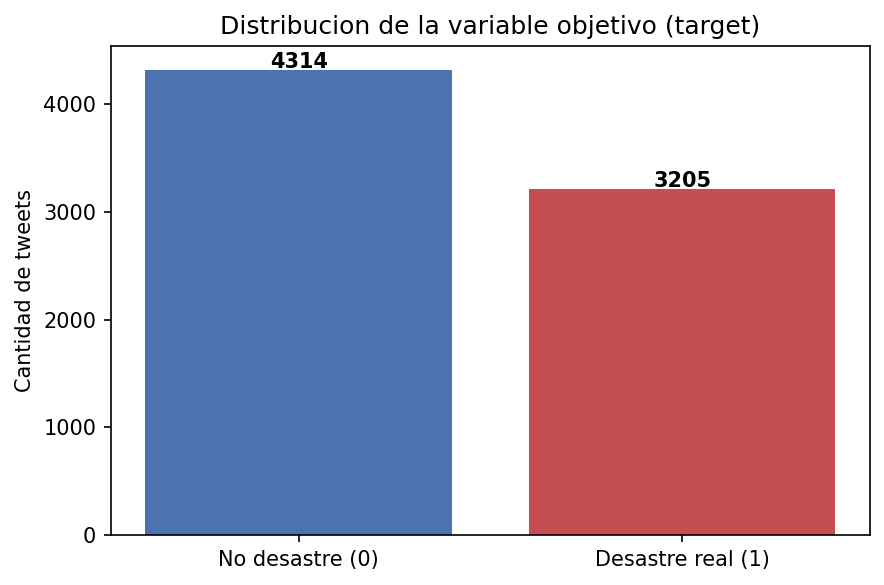

In [9]:
# Figura 1. Distribucion de la clase objetivo
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['target'].value_counts().sort_index()
labels = ['No desastre (0)', 'Desastre real (1)']
bars = ax.bar(labels, counts.values, color=['#4C72B0', '#C44E52'])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 20, str(val),
            ha='center', fontweight='bold')
ax.set_title('Distribucion de la variable objetivo (target)')
ax.set_ylabel('Cantidad de tweets')
plt.tight_layout()
plt.savefig(FIG_DIR + "01_distribucion_target.png")
plt.show()

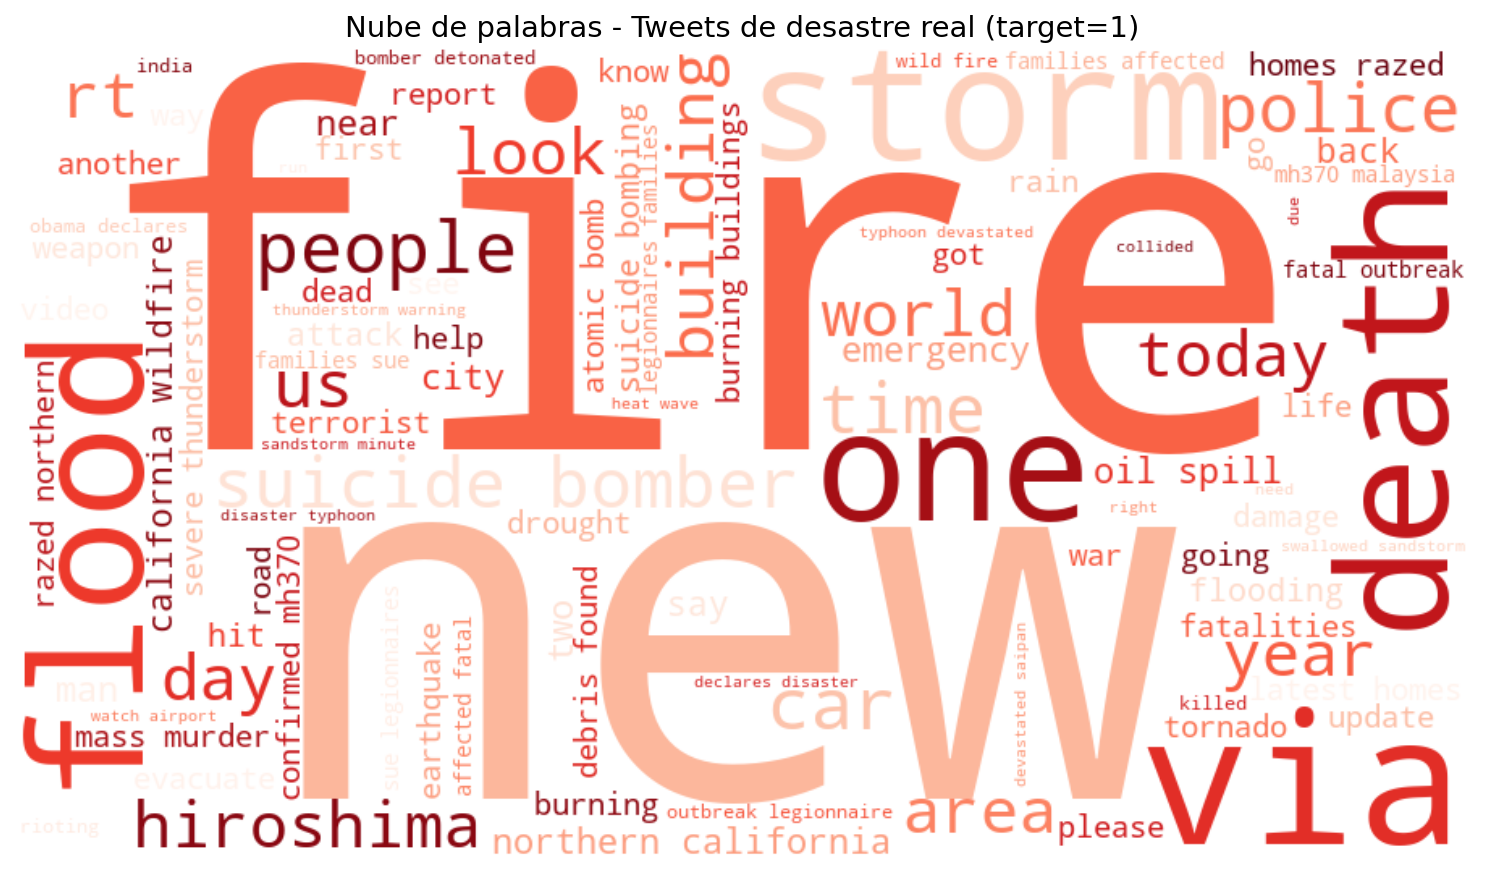

In [10]:
# Figura 5. Nube de palabras - Desastre real
wc_desastre = WordCloud(width=900, height=500, background_color='white',
                         colormap='Reds', max_words=100).generate(
    ' '.join(desastre))
plt.figure(figsize=(10, 6))
plt.imshow(wc_desastre, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras - Tweets de desastre real (target=1)', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR + "02_wordcloud_desastre.png")
plt.show()

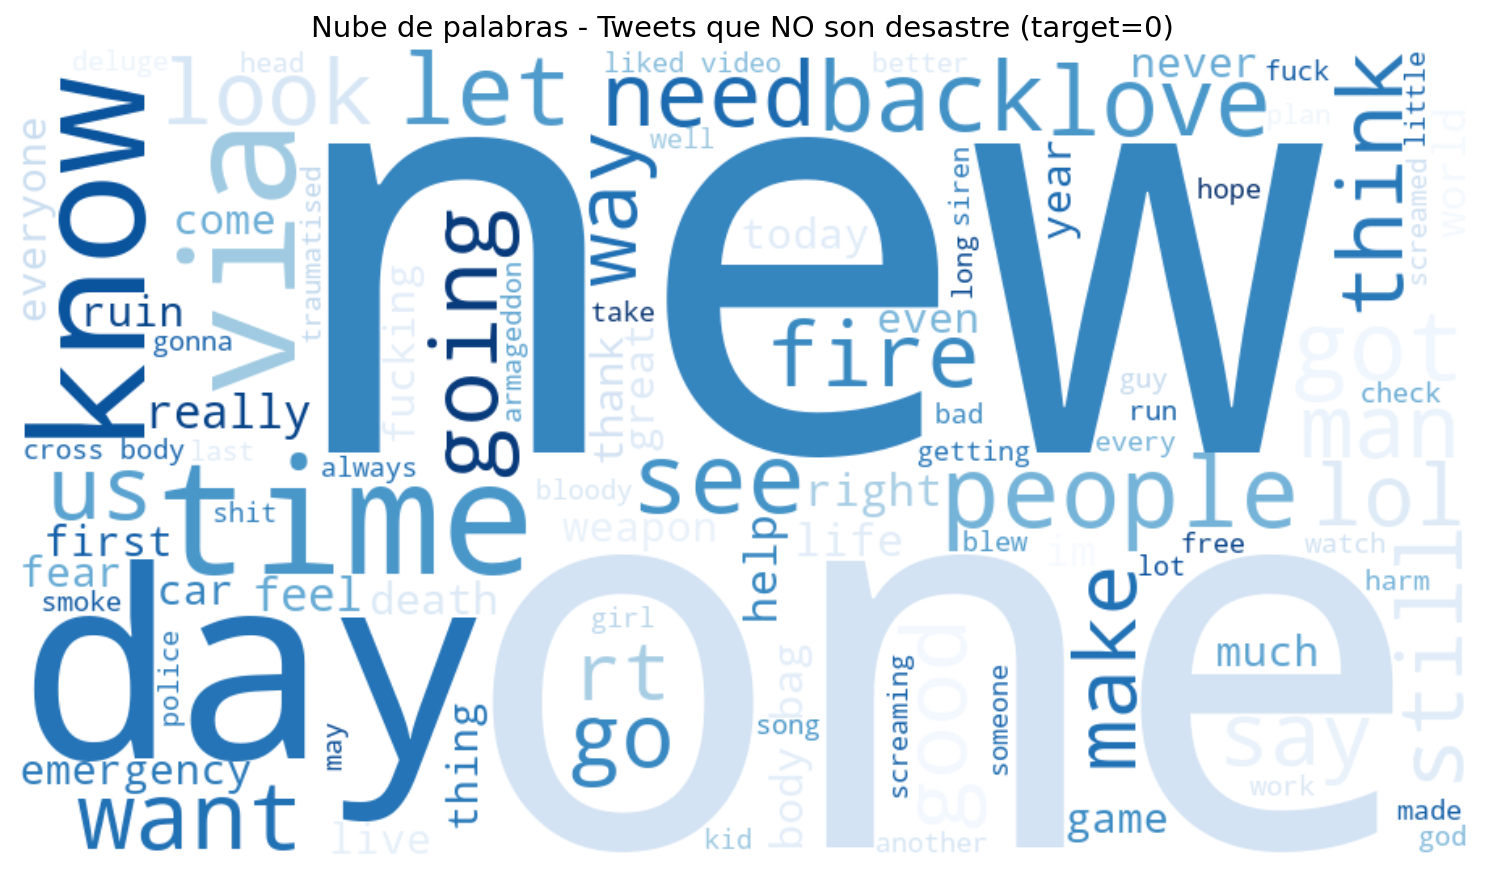

In [11]:
# Figura 6. Nube de palabras - No desastre
wc_no_desastre = WordCloud(width=900, height=500, background_color='white',
                            colormap='Blues', max_words=100).generate(
    ' '.join(no_desastre))
plt.figure(figsize=(10, 6))
plt.imshow(wc_no_desastre, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras - Tweets que NO son desastre (target=0)', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR + "03_wordcloud_no_desastre.png")
plt.show()

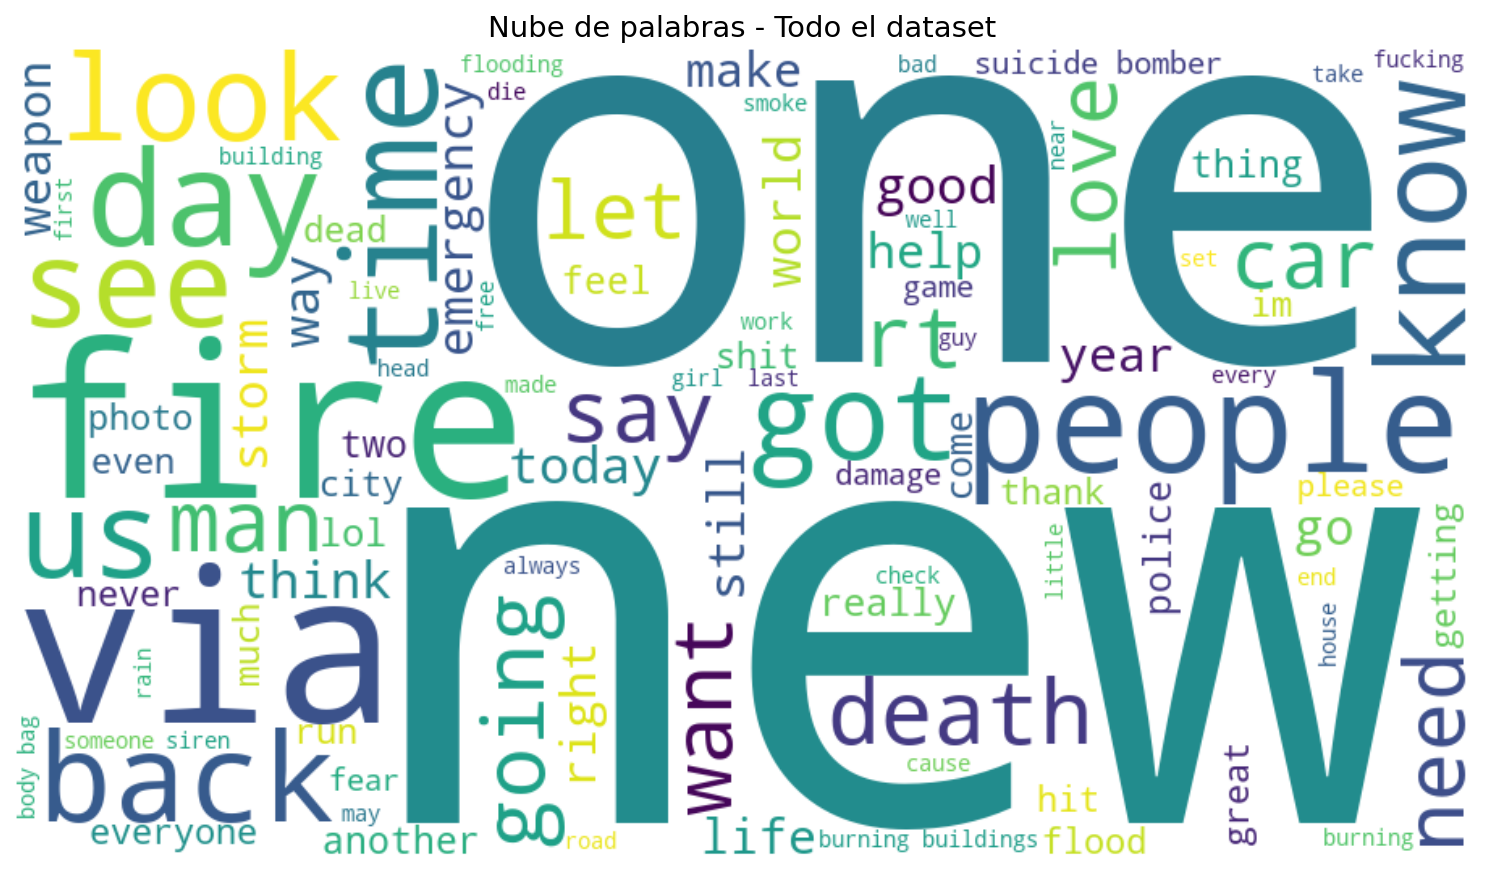

In [12]:
# Nube de palabras - Dataset completo (no numerada en el informe)
wc_general = WordCloud(width=900, height=500, background_color='white',
                        colormap='viridis', max_words=100).generate(
    ' '.join(df['text_clean']))
plt.figure(figsize=(10, 6))
plt.imshow(wc_general, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras - Todo el dataset', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR + "04_wordcloud_general.png")
plt.show()

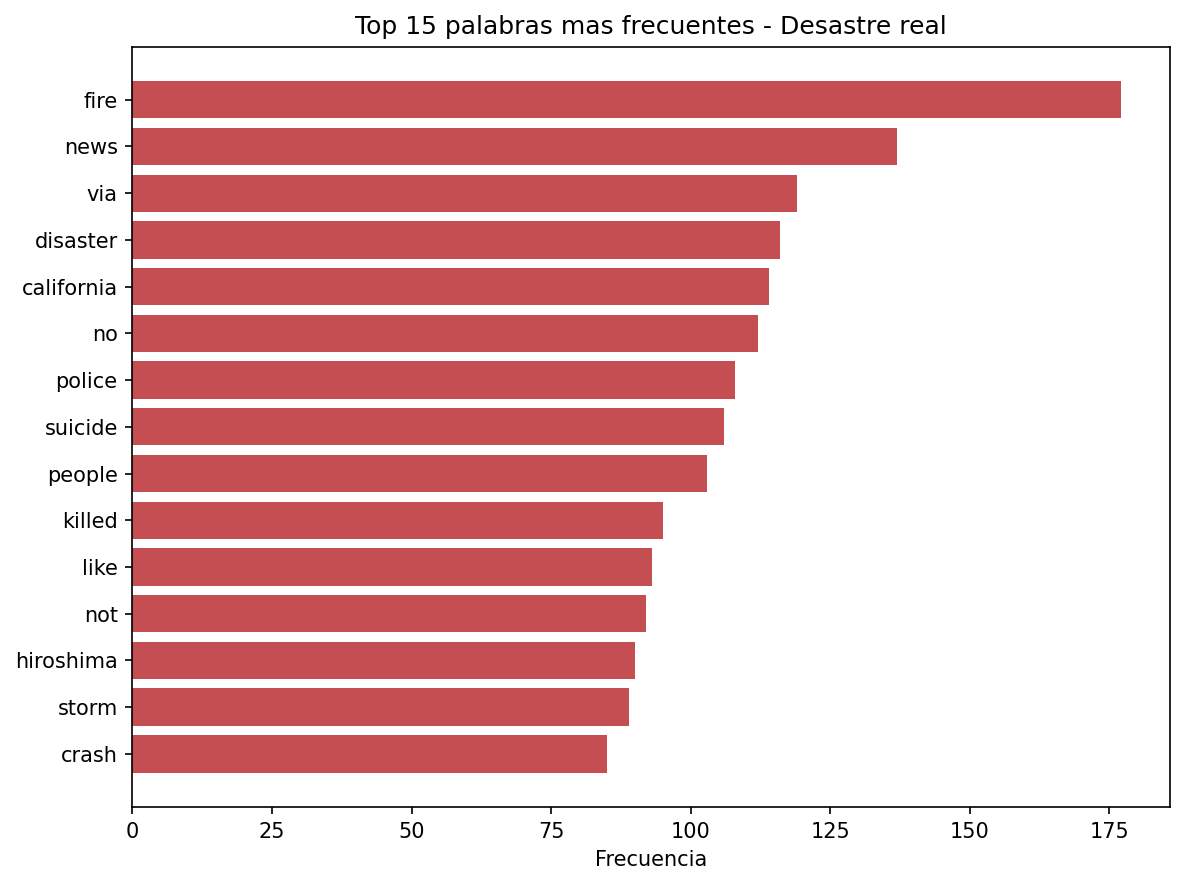

In [13]:
def get_top_n(corpus, n=15, ngram_range=(1, 1)):
    vec = CountVectorizer(ngram_range=ngram_range)
    matrix = vec.fit_transform(corpus)
    sums = matrix.sum(axis=0)
    freqs = [(word, sums[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(freqs, key=lambda x: x[1], reverse=True)[:n]


# Figura 2. Histograma top 15 unigramas - Desastre
top_d = get_top_n(desastre, 15)
fig, ax = plt.subplots(figsize=(8, 6))
words, counts_ = zip(*top_d)
ax.barh(words[::-1], counts_[::-1], color='#C44E52')
ax.set_title('Top 15 palabras mas frecuentes - Desastre real')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.savefig(FIG_DIR + "05_top_palabras_desastre.png")
plt.show()

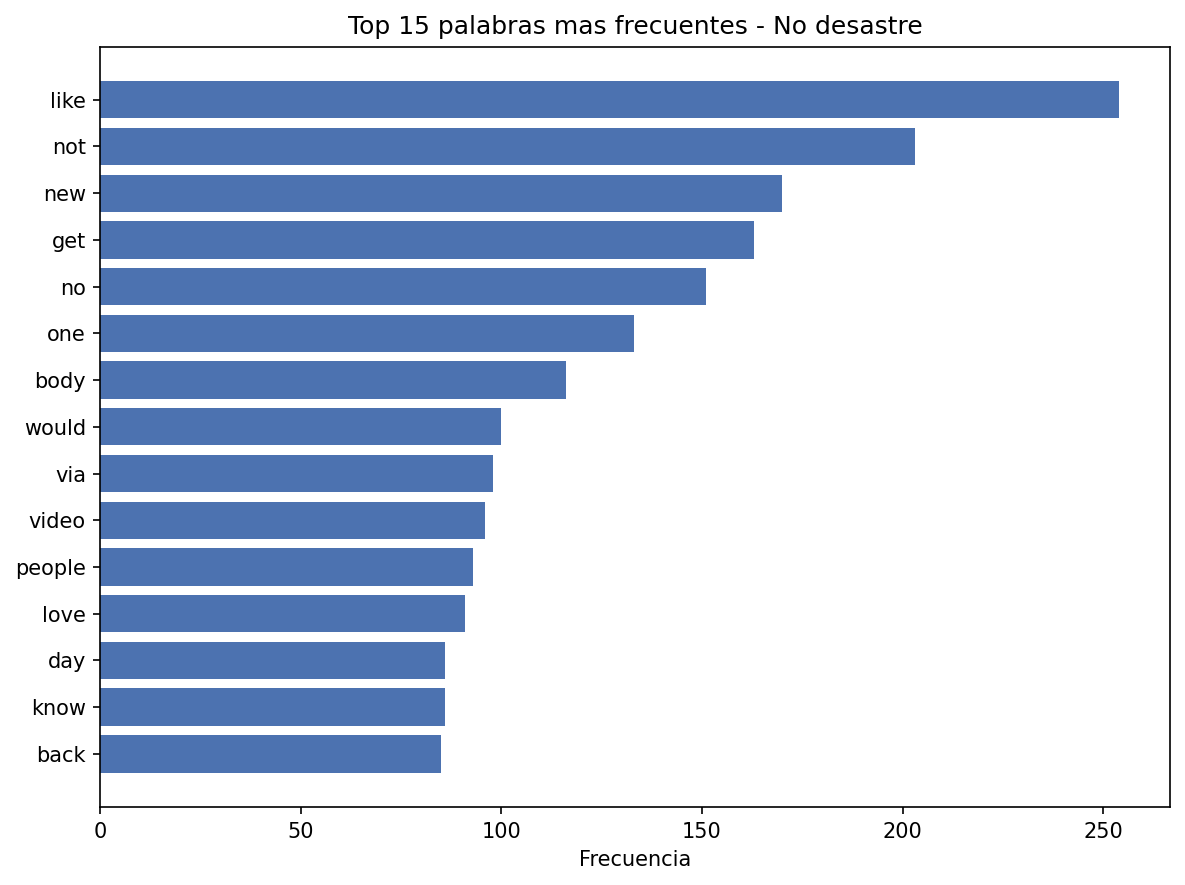

In [14]:
# Figura 3. Histograma top 15 unigramas - No desastre
top_nd = get_top_n(no_desastre, 15)
fig, ax = plt.subplots(figsize=(8, 6))
words, counts_ = zip(*top_nd)
ax.barh(words[::-1], counts_[::-1], color='#4C72B0')
ax.set_title('Top 15 palabras mas frecuentes - No desastre')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.savefig(FIG_DIR + "06_top_palabras_no_desastre.png")
plt.show()

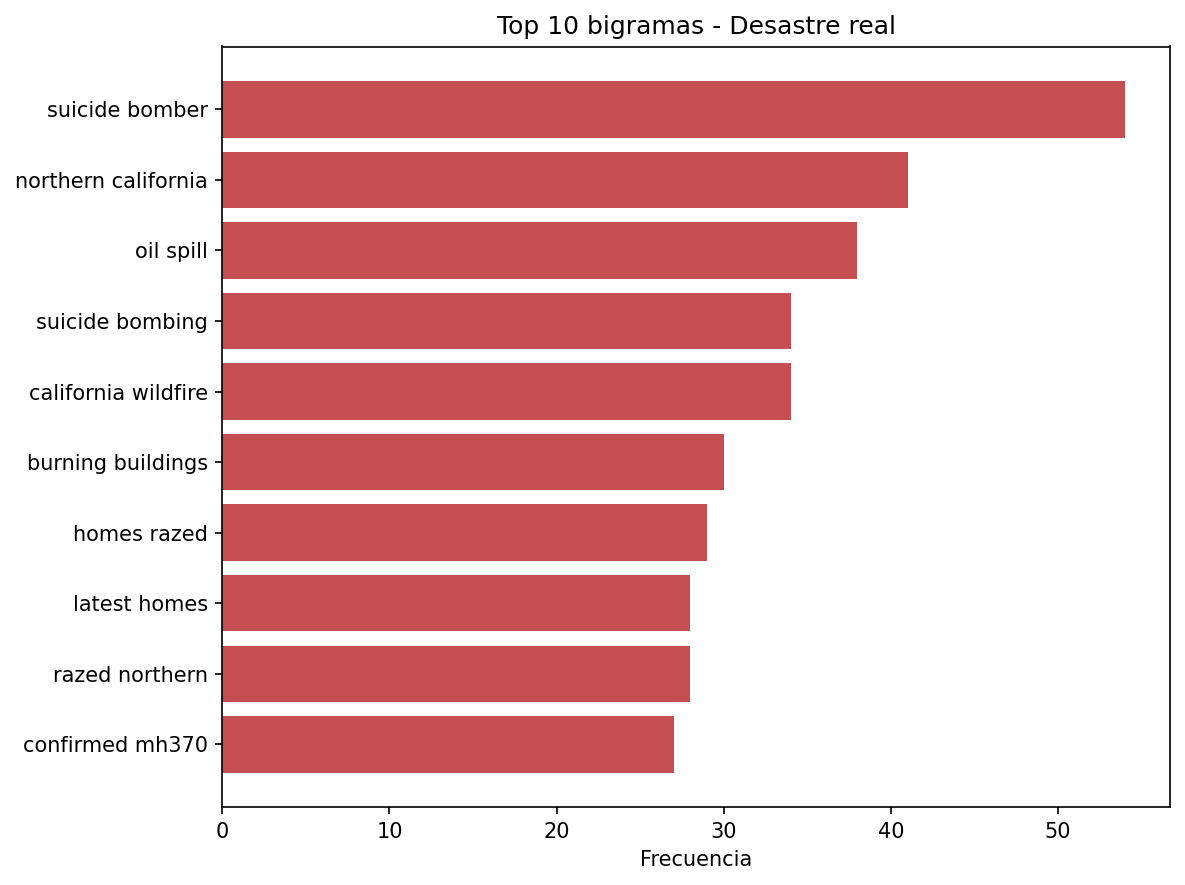

In [15]:
# Figura 4. Top bigramas - Desastre real
top_bi_d = get_top_n(desastre, 10, (2, 2))
fig, ax = plt.subplots(figsize=(8, 6))
words, counts_ = zip(*top_bi_d)
ax.barh(words[::-1], counts_[::-1], color='#C44E52')
ax.set_title('Top 10 bigramas - Desastre real')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.savefig(FIG_DIR + "07_top_bigramas_desastre.png")
plt.show()

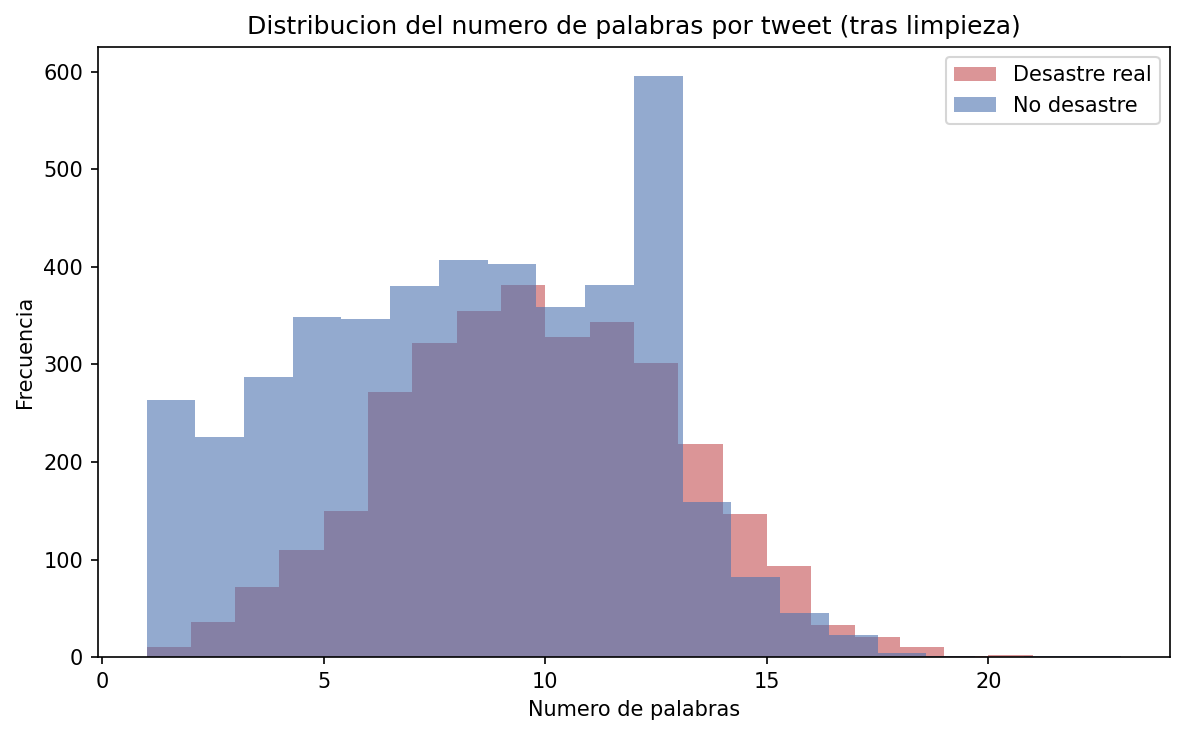

In [16]:
# Figura 7. Longitud de tweets (palabras) por categoria
fig, ax = plt.subplots(figsize=(8, 5))
df[df['target'] == 1]['clean_word_count'].plot.hist(
    ax=ax, bins=20, alpha=0.6, color='#C44E52', label='Desastre real')
df[df['target'] == 0]['clean_word_count'].plot.hist(
    ax=ax, bins=20, alpha=0.6, color='#4C72B0', label='No desastre')
ax.set_title('Distribucion del numero de palabras por tweet (tras limpieza)')
ax.set_xlabel('Numero de palabras')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + "08_longitud_tweets.png")
plt.show()

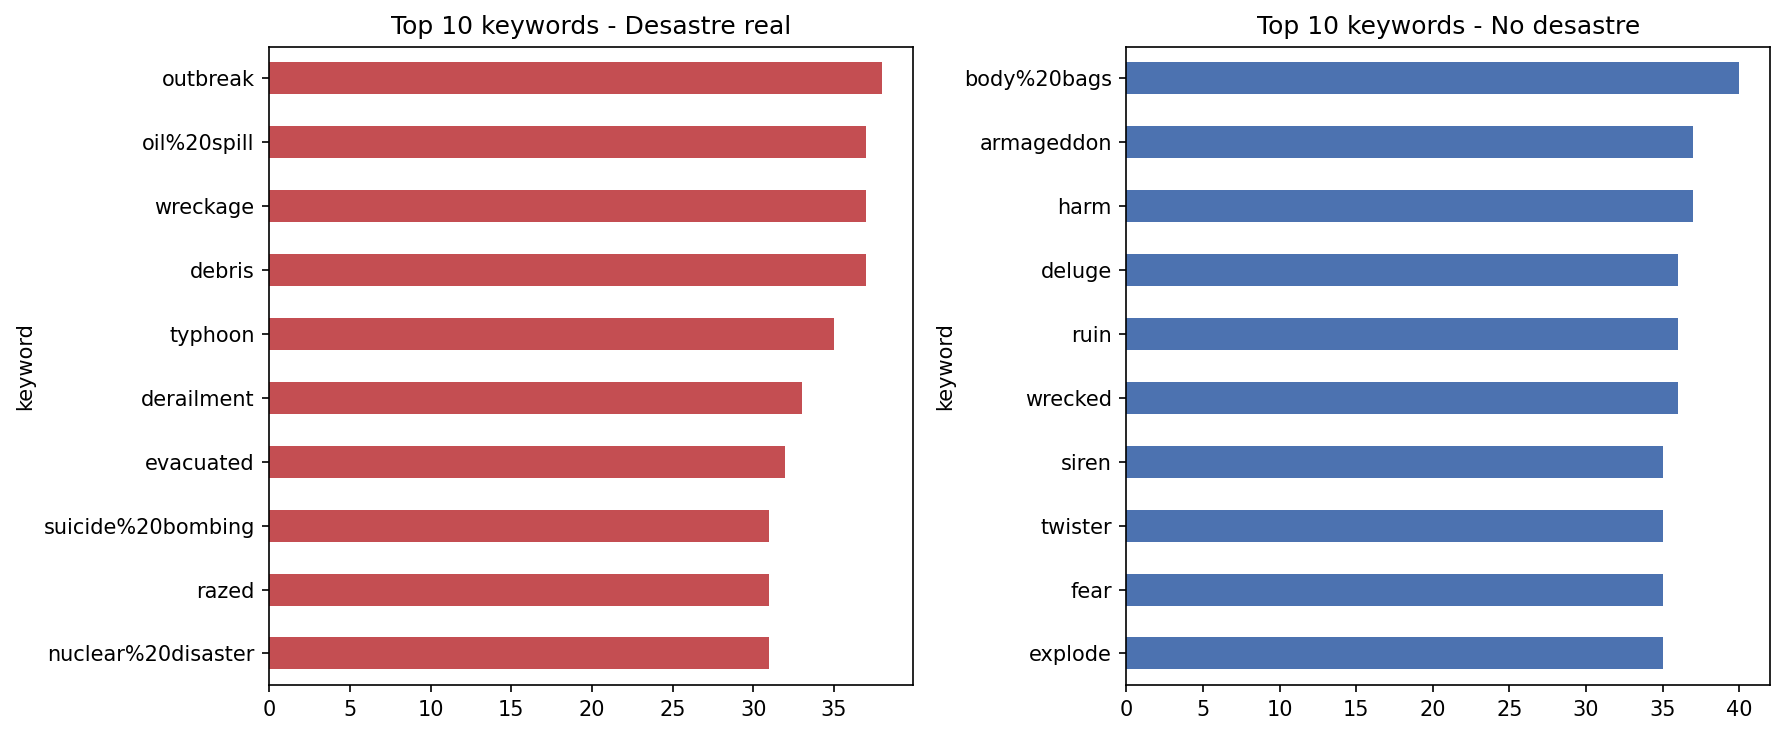


Figuras generadas en figures/
['01_distribucion_target.png', '02_wordcloud_desastre.png', '03_wordcloud_no_desastre.png', '04_wordcloud_general.png', '05_top_palabras_desastre.png', '06_top_palabras_no_desastre.png', '07_top_bigramas_desastre.png', '08_longitud_tweets.png', '09_top_keywords.png', '10_confusion_naive_bayes_multinomial.png', '10_confusion_regresion_logistica.png', '11_comparacion_modelos.png', '12_cv_comparacion_modelos.png', '13_matriz_confusion_mejor.png', '14_roc_mejor_modelo.png']


In [17]:
# Figura 8. Top keywords por categoria (columna 'keyword' original)
kw = df.dropna(subset=['keyword'])
top_kw_d = kw[kw['target'] == 1]['keyword'].value_counts().head(10)
top_kw_nd = kw[kw['target'] == 0]['keyword'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top_kw_d.sort_values().plot.barh(ax=axes[0], color='#C44E52')
axes[0].set_title('Top 10 keywords - Desastre real')
top_kw_nd.sort_values().plot.barh(ax=axes[1], color='#4C72B0')
axes[1].set_title('Top 10 keywords - No desastre')
plt.tight_layout()
plt.savefig(FIG_DIR + "09_top_keywords.png")
plt.show()

print("\nFiguras generadas en", FIG_DIR)
import os
print(sorted(os.listdir(FIG_DIR)))

**Interpretación del análisis exploratorio:**

- La distribución de la **longitud de tweets** (en palabras, tras la limpieza) es **similar entre ambas categorías**, con una media alrededor de 9–10 palabras; no parece ser, por sí sola, una variable fuertemente discriminante, pero se mantendrá disponible como posible feature adicional (Figura 7).
- La columna `keyword` (proporcionada en el dataset original, antes de la limpieza de texto libre) confirma el patrón: keywords como `derailment`, `wreckage`, `debris` y `outbreak` están fuertemente asociadas a tweets de desastre real, mientras que otras keywords ambiguas (ej. `body bags`, `panic`) aparecen en ambas categorías dependiendo del uso figurado o literal del término (Figura 8).
- Las nubes de palabras (Figuras 5 y 6) confirman el patrón: en desastres dominan `fire`, `disaster`, `suicide`, `police`, `storm`; en no-desastre dominan palabras de uso cotidiano.

**Discusión sobre las palabras que tienen presencia en todas las categorías.**

Hay 14 palabras en el top 50 de **ambas** categorías (ver sección 4.1). Son ambiguas por sí solas y su poder discriminante depende del contexto en que aparecen; por eso el modelo se apoya en combinaciones de palabras (bigramas) y en el contexto local, no solo en la presencia o ausencia de un único término concreto.

## 6. Modelo preliminar de clasificación (Ejercicio 6)

Para abordar el problema de contexto discutido en la sección 4.2, se representó cada tweet limpio mediante **TF-IDF con unigramas y bigramas** (`ngram_range=(1,2)`), limitando el vocabulario a las **5 000 características** más relevantes para controlar la dimensionalidad. Se separó el conjunto en **80 % entrenamiento y 20 % prueba**, de forma estratificada para conservar la proporción de clases.

Como modelos preliminares (baseline) se entrenaron dos algoritmos ampliamente usados en clasificación de texto: **Regresión Logística** y **Naive Bayes Multinomial**. Ambos son rápidos de entrenar y sirven como punto de comparación para los modelos más elaborados que se explorarán en la entrega final (ej. SVM, Random Forest, redes neuronales simples). Se evaluaron accuracy, precisión, recall y F1, además de matrices de confusión.

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/train_clean.csv")
df = df.dropna(subset=['text_clean'])
df = df[df['text_clean'].str.len() > 0]

X = df['text_clean']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Entrenamiento: {len(X_train)} tweets | Prueba: {len(X_test)} tweets")

# TF-IDF con unigramas + bigramas para capturar contexto
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Entrenamiento: 6015 tweets | Prueba: 1504 tweets



Regresion Logistica


               precision    recall  f1-score   support

  No desastre       0.79      0.89      0.83       863
Desastre real       0.82      0.68      0.74       641

     accuracy                           0.80      1504
    macro avg       0.80      0.78      0.79      1504
 weighted avg       0.80      0.80      0.80      1504



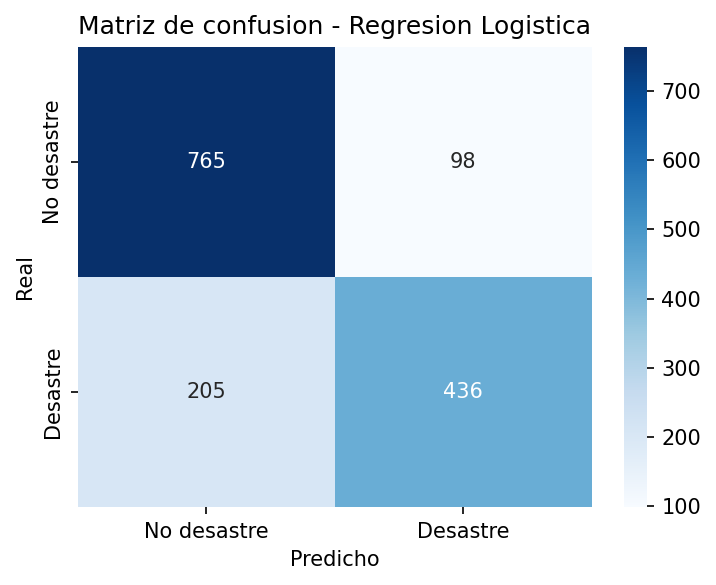


Naive Bayes Multinomial
               precision    recall  f1-score   support

  No desastre       0.78      0.91      0.84       863
Desastre real       0.85      0.66      0.74       641

     accuracy                           0.80      1504
    macro avg       0.81      0.78      0.79      1504
 weighted avg       0.81      0.80      0.80      1504



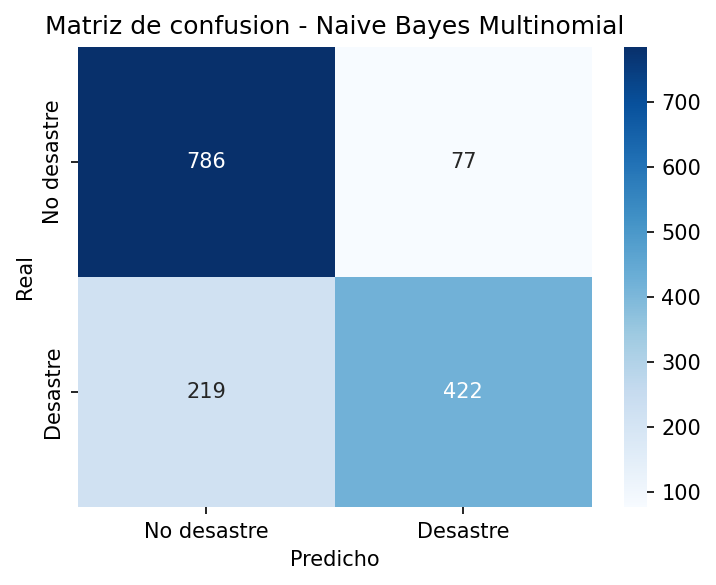


Resumen comparativo de modelos preliminares:
                    modelo  accuracy  precision  recall      f1
0      Regresion Logistica    0.7985     0.8165  0.6802  0.7421
1  Naive Bayes Multinomial    0.8032     0.8457  0.6583  0.7404


In [19]:
modelos = {
    "Regresion Logistica": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes Multinomial": MultinomialNB(),
}

resultados = []
for nombre, modelo in modelos.items():
    modelo.fit(X_train_tfidf, y_train)
    y_pred = modelo.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{'='*50}\n{nombre}\n{'='*50}")
    print(classification_report(y_test, y_pred,
                                 target_names=['No desastre', 'Desastre real']))

    resultados.append({
        "modelo": nombre, "accuracy": acc, "precision": prec,
        "recall": rec, "f1": f1
    })

    # Matriz de confusion
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No desastre', 'Desastre'],
                yticklabels=['No desastre', 'Desastre'])
    ax.set_title(f'Matriz de confusion - {nombre}')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')
    plt.tight_layout()
    safe_name = nombre.lower().replace(' ', '_')
    plt.savefig(f"figures/10_confusion_{safe_name}.png")
    plt.show()

res_df = pd.DataFrame(resultados)
print("\nResumen comparativo de modelos preliminares:")
print(res_df.round(4))
res_df.to_csv("data/resultados_modelo_preliminar.csv", index=False)

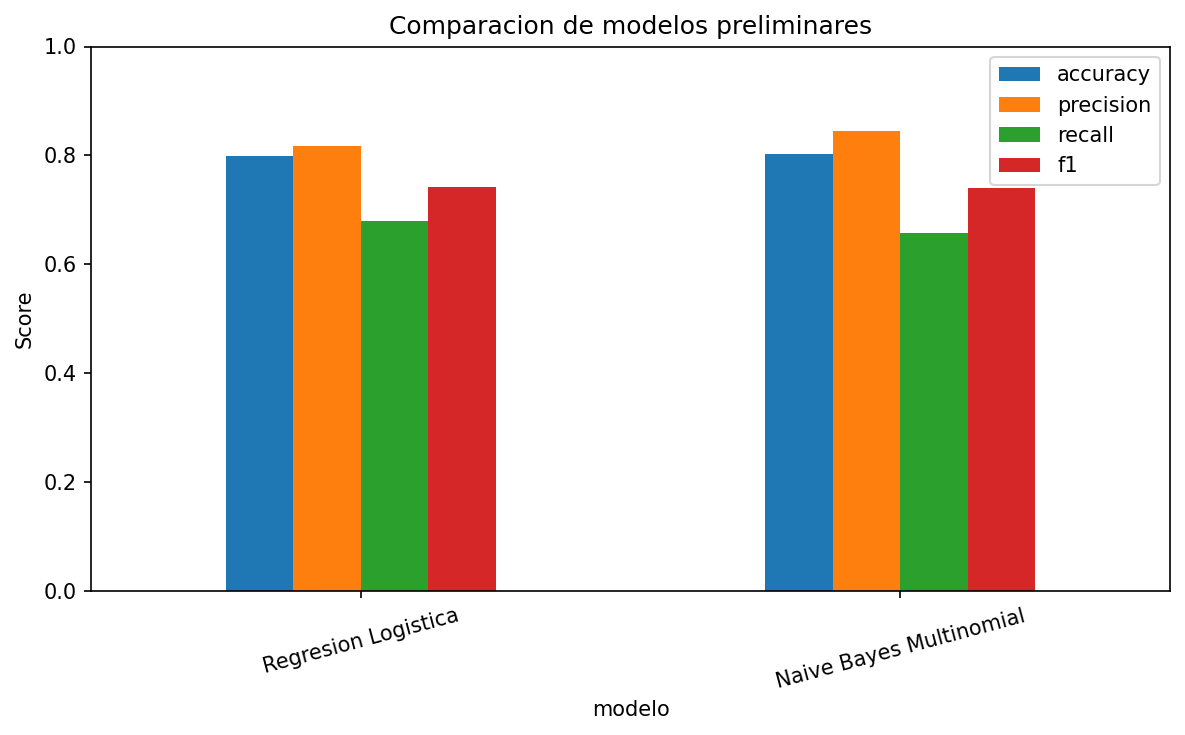

In [20]:
# Figura 9. Grafico comparativo de metricas
fig, ax = plt.subplots(figsize=(8, 5))
res_df.set_index('modelo')[['accuracy', 'precision', 'recall', 'f1']].plot.bar(ax=ax)
ax.set_title('Comparacion de modelos preliminares')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("figures/11_comparacion_modelos.png")
plt.show()

**Resultados (Tabla 3 del informe — métricas de los modelos preliminares sobre el conjunto de prueba, 20 %):**

| Modelo | Accuracy | Precision | Recall | F1-score |
|---|---|---|---|---|
| Regresión Logística | 0.796 | 0.812 | 0.679 | 0.739 |
| Naive Bayes Multinomial | 0.802 | 0.846 | 0.654 | 0.738 |

*(La **Figura 9** del informe compara visualmente las métricas; la **Figura 10** muestra la matriz de confusión de la Regresión Logística.)*

**Observaciones:**

- Ambos modelos alcanzan un accuracy cercano al **80 %** únicamente con TF-IDF de texto, sin ninguna variable adicional.
- Naive Bayes obtiene mayor precisión (menos falsos positivos), mientras que Regresión Logística obtiene un recall ligeramente mayor.
- Se observa que el **recall de la clase "desastre real"** (0.65–0.68) es menor que el de la clase "no desastre", lo que indica que ambos modelos tienden a perder algunos tweets de desastre real, probablemente aquellos que usan lenguaje menos directo o palabras ambiguas discutidas en la sección 4.
- Estos resultados son un punto de partida razonable. En la entrega final se probarán más algoritmos, se realizará ajuste de hiperparámetros y se incorporará la variable de "negatividad" del tweet (análisis de sentimiento) para evaluar si mejora la capacidad de detectar tweets de desastre real, particularmente el recall de esa clase.

> La ampliación con más algoritmos, validación cruzada y selección del mejor modelo se desarrolla en la **sección 6.1**.

### 6.1 Comparación de múltiples algoritmos (continuación del Ejercicio 6)

Se amplía el baseline probando varios algoritmos de clasificación. **¿Cómo se aborda el contexto?**

- **Representación**: TF-IDF de unigramas + bigramas (`ngram_range=(1,2)`, 5 000 características), igual que el baseline, para capturar contexto local: la combinación *fire + building* es más informativa que la palabra *fire* aislada.
- **Validación cruzada estratificada (5 folds)** para comparar los modelos de forma robusta, sin depender de una sola partición.
- **Algoritmos probados**: Regresión Logística, Naive Bayes Multinomial, SVM lineal (`LinearSVC`), Random Forest y KNN (baseline de distancia).
- **Ajuste de hiperparámetros** (`GridSearchCV`, 3 folds) para Regresión Logística, SVM lineal y Random Forest.
- **Selección del mejor modelo por F1 macro** sobre el conjunto de prueba, más representativo ante el leve desbalance de clases que la exactitud.
- **Curva ROC**, guardado del modelo y función para clasificar tweets nuevos sin preprocesar.

In [21]:
%matplotlib inline
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, GridSearchCV)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from nltk.corpus import stopwords

# Funcion de limpieza (identica a la del paso 2), necesaria para predecir
# tweets nuevos que no estan preprocesados.
STOPWORDS = set(stopwords.words('english'))
NEGATIONS = {"no", "not", "nor"}
STOPWORDS = STOPWORDS - NEGATIONS

URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
HASHTAG_SYMBOL_RE = re.compile(r'#')
HTML_ENTITY_RE = re.compile(r'&\w+;')
EMOJI_RE = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U0001F900-\U0001F9FF"
    "\U00002600-\U000026FF"
    "]+", flags=re.UNICODE
)
PUNCT_RE = re.compile(r"[^\w\s]")
NUMBER_RE = re.compile(r'\b\d+\b')
MULTISPACE_RE = re.compile(r'\s+')


def clean_text(text: str, keep_911: bool = True) -> str:
    text = str(text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = text.lower()
    text = URL_RE.sub(' ', text)
    text = MENTION_RE.sub(' ', text)
    text = HASHTAG_SYMBOL_RE.sub('', text)
    text = EMOJI_RE.sub(' ', text)
    text = HTML_ENTITY_RE.sub(' ', text)
    text = text.replace('_', ' ')
    if keep_911:
        text = text.replace('911', ' NUM911TOKEN ')
    text = PUNCT_RE.sub(' ', text)
    text = NUMBER_RE.sub(' ', text)
    if keep_911:
        text = text.replace('num911token', ' 911 ')
    text = MULTISPACE_RE.sub(' ', text).strip()
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]
    return ' '.join(tokens)


# Carga y particion (misma configuracion que el baseline, para comparar)
df = pd.read_csv("data/train_clean.csv")
df = df.dropna(subset=['text_clean'])
df = df[df['text_clean'].str.len() > 0]

X = df['text_clean']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Entrenamiento: {len(X_train)} tweets | Prueba: {len(X_test)} tweets")

vectorizer2 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
Xtr = vectorizer2.fit_transform(X_train)
Xte = vectorizer2.transform(X_test)

Entrenamiento: 6015 tweets | Prueba: 1504 tweets


VALIDACION CRUZADA (5 folds, datos de entrenamiento)



Regresion Logistica
  accuracy          : 0.7962 +/- 0.0138
  precision_macro   : 0.8045 +/- 0.0147
  recall_macro      : 0.7782 +/- 0.0145
  f1_macro          : 0.7841 +/- 0.0150



Naive Bayes Multinomial
  accuracy          : 0.7972 +/- 0.0079
  precision_macro   : 0.8107 +/- 0.0065
  recall_macro      : 0.7768 +/- 0.0093
  f1_macro          : 0.7833 +/- 0.0093



SVM lineal (LinearSVC)
  accuracy          : 0.7792 +/- 0.0145
  precision_macro   : 0.7768 +/- 0.0158
  recall_macro      : 0.7687 +/- 0.0137
  f1_macro          : 0.7714 +/- 0.0143



Random Forest
  accuracy          : 0.7845 +/- 0.0117
  precision_macro   : 0.7886 +/- 0.0124
  recall_macro      : 0.7682 +/- 0.0125
  f1_macro          : 0.7731 +/- 0.0127


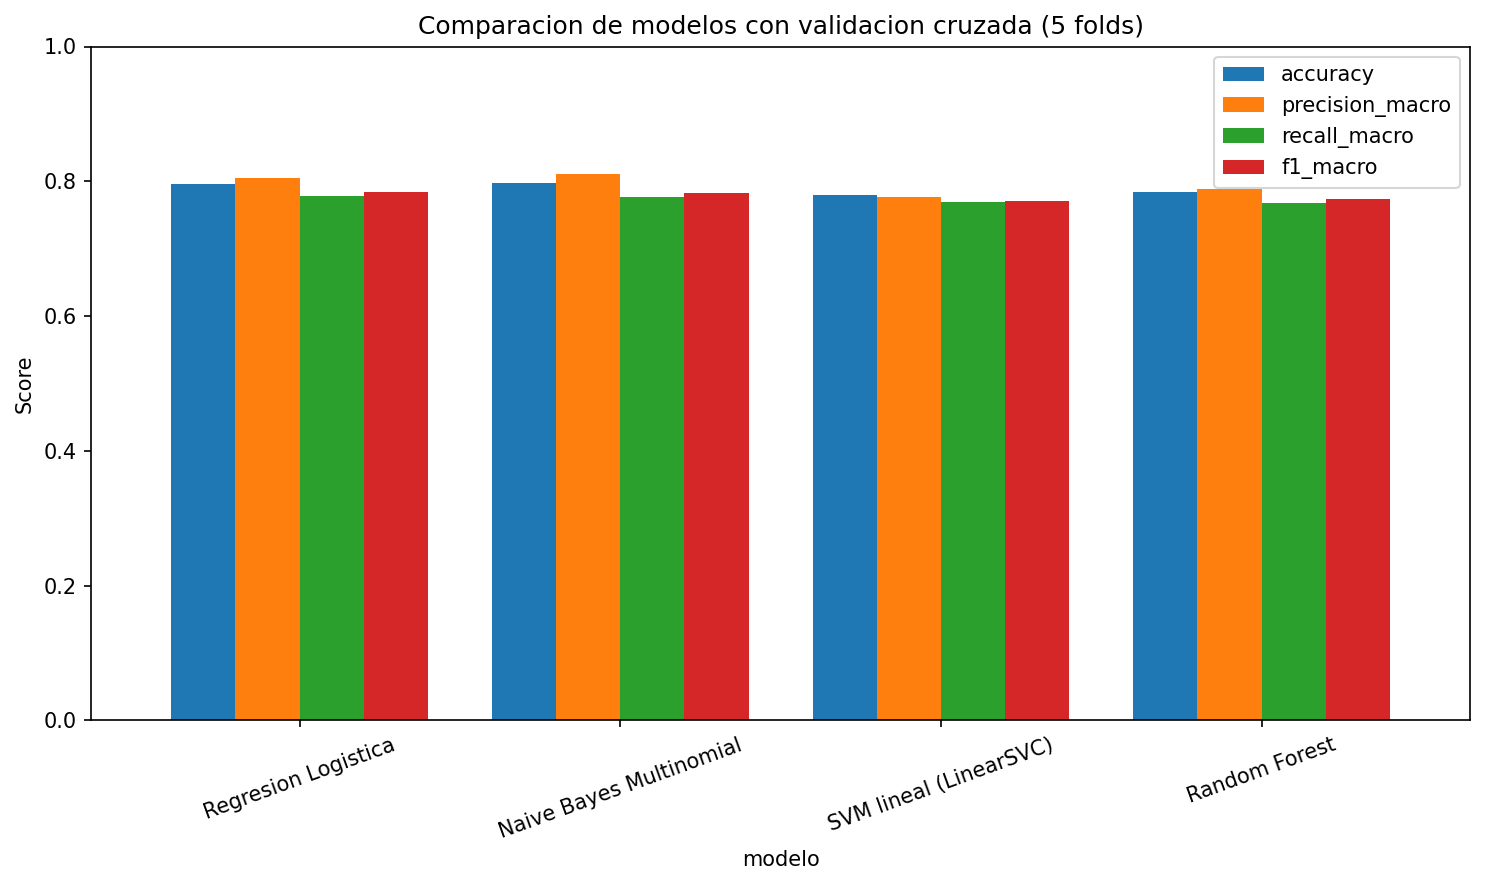

In [22]:
# KNN es muy costoso en CV sobre TF-IDF de alta dimension:
# se excluye del CV y solo se evalua en el conjunto de prueba.
MODELOS_CV = {
    "Regresion Logistica": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes Multinomial": MultinomialNB(),
    "SVM lineal (LinearSVC)": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42,
                                            n_jobs=-1),
}

SCORING = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("VALIDACION CRUZADA (5 folds, datos de entrenamiento)")
filas_cv = []
for nombre, modelo in MODELOS_CV.items():
    cv_res = cross_validate(modelo, Xtr, y_train, cv=cv, scoring=SCORING,
                            n_jobs=-1)
    fila = {"modelo": nombre}
    for m in SCORING:
        fila[m] = cv_res[f"test_{m}"].mean().round(4)
        fila[m + "_std"] = cv_res[f"test_{m}"].std().round(4)
    filas_cv.append(fila)
    print(f"\n{nombre}")
    for m in SCORING:
        print(f"  {m:18s}: {fila[m]:.4f} +/- {fila[m+'_std']:.4f}")

cv_df = pd.DataFrame(filas_cv)
cv_df.to_csv("data/resultados_cv_modelos.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 6))
cv_df.set_index('modelo')[['accuracy', 'precision_macro', 'recall_macro',
                           'f1_macro']].plot.bar(ax=ax, width=0.8)
ax.set_title('Comparacion de modelos con validacion cruzada (5 folds)')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("figures/12_cv_comparacion_modelos.png")
plt.show()

In [23]:
gcv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
base_estimadores = {
    "Regresion Logistica": LogisticRegression(max_iter=1000, random_state=42),
    "SVM lineal (LinearSVC)": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
}
param_grids = {
    "Regresion Logistica": {"C": [0.1, 1, 10]},
    "SVM lineal (LinearSVC)": {"C": [0.1, 1, 10]},
    "Random Forest": {"n_estimators": [200, 300]},
}

print("AJUSTE DE HIPERPARAMETROS (GridSearchCV, 3 folds)")
mejores_modelos2 = {}
for nombre, base in base_estimadores.items():
    gs = GridSearchCV(base, param_grids[nombre], scoring='f1_macro', cv=gcv,
                      n_jobs=-1)
    gs.fit(Xtr, y_train)
    mejores_modelos2[nombre] = gs.best_estimator_
    print(f"{nombre} -> hiperparametros: {gs.best_params_} "
          f"| F1 macro (CV): {gs.best_score_:.4f}")

for nombre in MODELOS_CV:
    if nombre not in mejores_modelos2:
        mejores_modelos2[nombre] = MODELOS_CV[nombre]
mejores_modelos2["KNN (k=5)"] = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)


def evaluar(modelo, X_te, y_te):
    y_pred = modelo.predict(X_te)
    return {
        "accuracy": accuracy_score(y_te, y_pred),
        "precision_macro": precision_score(y_te, y_pred, average='macro'),
        "recall_macro": recall_score(y_te, y_pred, average='macro'),
        "f1_macro": f1_score(y_te, y_pred, average='macro'),
        "f1_weighted": f1_score(y_te, y_pred, average='weighted'),
    }


print("\nEVALUACION FINAL SOBRE EL CONJUNTO DE PRUEBA (20%)")
filas_test = []
for nombre, modelo in mejores_modelos2.items():
    modelo.fit(Xtr, y_train)
    y_pred2 = modelo.predict(Xte)
    m = evaluar(modelo, Xte, y_test)
    m["modelo"] = nombre
    filas_test.append(m)
    print(f"\n{nombre} | acc={m['accuracy']:.4f} | f1_macro={m['f1_macro']:.4f}")
    print(classification_report(y_test, y_pred2,
                                target_names=['No desastre', 'Desastre real']))

test_df = pd.DataFrame(filas_test).set_index('modelo')
test_df = test_df[['accuracy', 'precision_macro', 'recall_macro', 'f1_macro',
                   'f1_weighted']]
print("\nResumen comparativo en prueba:")
print(test_df.round(4))
test_df.round(4).to_csv("data/resultados_modelos_finales.csv")

# Seleccion del mejor modelo por F1 macro en prueba
mejor_nombre = test_df['f1_macro'].idxmax()
mejor_modelo2 = mejores_modelos2[mejor_nombre]
print("\nMEJOR MODELO:", mejor_nombre)
print("F1 macro en prueba:", round(test_df.loc[mejor_nombre, 'f1_macro'], 4))
print("Accuracy en prueba:", round(test_df.loc[mejor_nombre, 'accuracy'], 4))

AJUSTE DE HIPERPARAMETROS (GridSearchCV, 3 folds)


Regresion Logistica -> hiperparametros: {'C': 1} | F1 macro (CV): 0.7808
SVM lineal (LinearSVC) -> hiperparametros: {'C': 0.1} | F1 macro (CV): 0.7782


Random Forest -> hiperparametros: {'n_estimators': 200} | F1 macro (CV): 0.7712

EVALUACION FINAL SOBRE EL CONJUNTO DE PRUEBA (20%)

Regresion Logistica | acc=0.7985 | f1_macro=0.7884
               precision    recall  f1-score   support

  No desastre       0.79      0.89      0.83       863
Desastre real       0.82      0.68      0.74       641

     accuracy                           0.80      1504
    macro avg       0.80      0.78      0.79      1504
 weighted avg       0.80      0.80      0.80      1504


SVM lineal (LinearSVC) | acc=0.8005 | f1_macro=0.7899
               precision    recall  f1-score   support

  No desastre       0.79      0.89      0.84       863
Desastre real       0.82      0.68      0.74       641

     accuracy                           0.80      1504
    macro avg       0.81      0.78      0.79      1504
 weighted avg       0.80      0.80      0.80      1504




Random Forest | acc=0.7839 | f1_macro=0.7739
               precision    recall  f1-score   support

  No desastre       0.78      0.87      0.82       863
Desastre real       0.79      0.67      0.73       641

     accuracy                           0.78      1504
    macro avg       0.79      0.77      0.77      1504
 weighted avg       0.78      0.78      0.78      1504


Naive Bayes Multinomial | acc=0.8032 | f1_macro=0.7909
               precision    recall  f1-score   support

  No desastre       0.78      0.91      0.84       863
Desastre real       0.85      0.66      0.74       641

     accuracy                           0.80      1504
    macro avg       0.81      0.78      0.79      1504
 weighted avg       0.81      0.80      0.80      1504




KNN (k=5) | acc=0.6809 | f1_macro=0.6047
               precision    recall  f1-score   support

  No desastre       0.65      0.98      0.78       863
Desastre real       0.90      0.28      0.43       641

     accuracy                           0.68      1504
    macro avg       0.77      0.63      0.60      1504
 weighted avg       0.75      0.68      0.63      1504


Resumen comparativo en prueba:
                         accuracy  precision_macro  recall_macro  f1_macro  \
modelo                                                                       
Regresion Logistica        0.7985           0.8026        0.7833    0.7884   
SVM lineal (LinearSVC)     0.8005           0.8062        0.7845    0.7899   
Random Forest              0.7839           0.7851        0.7696    0.7739   
Naive Bayes Multinomial    0.8032           0.8139        0.7846    0.7909   
KNN (k=5)                  0.6809           0.7719        0.6298    0.6047   

                         f1_weighted  
modelo 

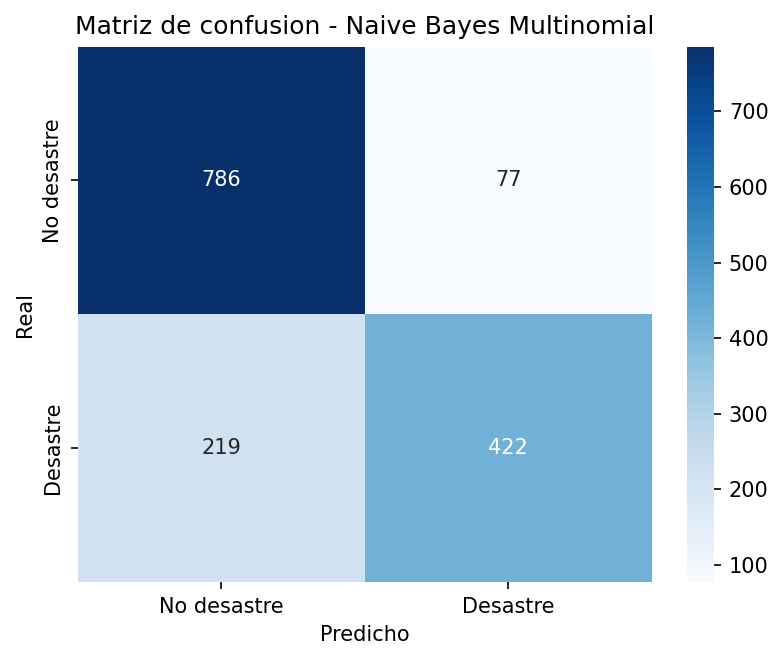

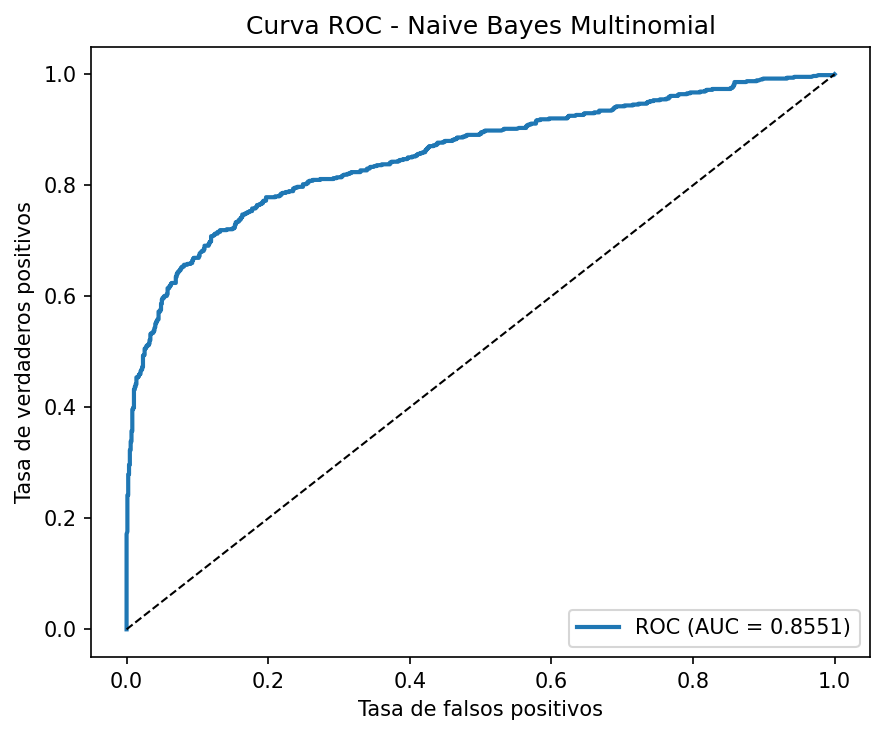

ROC AUC del mejor modelo: 0.8551


In [24]:
# Matriz de confusion del mejor modelo
y_pred_best = mejor_modelo2.predict(Xte)
cm2 = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No desastre', 'Desastre'],
            yticklabels=['No desastre', 'Desastre'])
ax.set_title(f'Matriz de confusion - {mejor_nombre}')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig("figures/13_matriz_confusion_mejor.png")
plt.show()

# Curva ROC del mejor modelo
if hasattr(mejor_modelo2, "predict_proba"):
    proba = mejor_modelo2.predict_proba(Xte)[:, 1]
else:
    proba = mejor_modelo2.decision_function(Xte)
roc_auc = roc_auc_score(y_test, proba)
fpr, tpr, _ = roc_curve(y_test, proba)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_title(f'Curva ROC - {mejor_nombre}')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("figures/14_roc_mejor_modelo.png")
plt.show()
print(f"ROC AUC del mejor modelo: {roc_auc:.4f}")

In [25]:
import os
os.makedirs("data/modelos", exist_ok=True)
joblib.dump(mejor_modelo2, "data/modelos/mejor_modelo.joblib")
joblib.dump(vectorizer2, "data/modelos/vectorizer.joblib")
info = pd.DataFrame([{
    "mejor_modelo": mejor_nombre,
    "f1_macro_test": test_df.loc[mejor_nombre, 'f1_macro'],
    "accuracy_test": test_df.loc[mejor_nombre, 'accuracy'],
    "roc_auc_test": roc_auc,
    "max_features": 5000,
    "ngram_range": "(1, 2)",
}])
info.to_csv("data/modelos/info_modelo.csv", index=False)
print("Modelo guardado en data/modelos/")


def predecir_tweet(texto: str) -> tuple:
    """Recibe un tweet sin preprocesar y devuelve la clasificacion."""
    limpio = clean_text(texto)
    x = vectorizer2.transform([limpio])
    pred = mejor_modelo2.predict(x)[0]
    if hasattr(mejor_modelo2, "predict_proba"):
        confianza = mejor_modelo2.predict_proba(x)[0][1]
    else:
        confianza = float(np.clip(mejor_modelo2.decision_function(x)[0], 0, 1))
    return int(pred), confianza, limpio


ejemplos = [
    "Forest fire near La Ronge Sask. Canada",
    "I love this new phone, it's fire!",
    "BREAKING: 7.1 magnitude earthquake hits Mexico City",
    "That concert was the bomb, best night ever",
]
for t in ejemplos:
    pred, conf, limpio = predecir_tweet(t)
    etiqueta = "DESASTRE" if pred == 1 else "no desastre"
    print(f"\nTweet: {t}")
    print(f"Limpio: {limpio}")
    print(f"Clasificacion: {etiqueta} (confianza: {conf:.3f})")

Modelo guardado en data/modelos/

Tweet: Forest fire near La Ronge Sask. Canada
Limpio: forest fire near la ronge sask canada
Clasificacion: DESASTRE (confianza: 0.909)

Tweet: I love this new phone, it's fire!
Limpio: love new phone fire
Clasificacion: no desastre (confianza: 0.104)

Tweet: BREAKING: 7.1 magnitude earthquake hits Mexico City
Limpio: breaking magnitude earthquake hits mexico city
Clasificacion: DESASTRE (confianza: 0.794)

Tweet: That concert was the bomb, best night ever
Limpio: concert bomb best night ever
Clasificacion: no desastre (confianza: 0.176)


### 6.2 Resultados de la comparación de modelos

**Métricas sobre el conjunto de prueba (20 %)**

| Modelo | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) |
|---|---|---|---|---|
| Regresión Logística | 0.7985 | 0.8026 | 0.7833 | 0.7884 |
| SVM lineal (LinearSVC) | 0.8005 | 0.8062 | 0.7845 | 0.7899 |
| Random Forest | 0.7839 | 0.7851 | 0.7696 | 0.7739 |
| **Naive Bayes Multinomial** | **0.8032** | **0.8139** | 0.7846 | **0.7909** |
| KNN (k=5) | 0.6809 | 0.7719 | 0.6298 | 0.6047 |

**El mejor modelo es Naive Bayes Multinomial**, con accuracy de 0.803, F1 macro de 0.791 y AUC-ROC de 0.855. Coincide con el desempeño observado en validación cruzada, donde los modelos lineales y bayesianos fueron los más estables (F1 macro 0.771–0.784) y KNN el peor (en CV se omite por costo; en prueba obtiene recall de apenas 0.28 en la clase "desastre real"). Esto confirma que la representación TF-IDF de alta dimensión y dispersa favorece a los modelos lineales/bayesianos sobre modelos basados en vecindad o árboles. La matriz de confusión y la curva ROC del mejor modelo quedan en `figures/` (`13_matriz_confusion_mejor.png`, `14_roc_mejor_modelo.png`) y el modelo + vectorizador en `data/modelos/`.

## 7. Próximos pasos

1. Incorporar la variable de "negatividad" (análisis de sentimiento) y, si es posible, features adicionales (ej. `keyword`) para evaluar si mejoran el recall de la clase "desastre real".
2. Consolidar la función `predecir_tweet` en un script ejecutable que reciba tweets sin preprocesar y devuelva la clasificación con su confianza.
3. Determinar palabras positivas, negativas y neutras por tweet (análisis de sentimiento) usando un léxico o librería como TextBlob/VADER.
4. Identificar los 10 tweets más positivos y más negativos, y comparar la negatividad entre categorías.
5. Consolidar todos los hallazgos en el informe final con las referencias de las herramientas externas utilizadas.

## 8. Referencias y herramientas utilizadas

- Librerías de Python: `pandas`, `scikit-learn` (CountVectorizer, TfidfVectorizer, LogisticRegression, MultinomialNB, LinearSVC, RandomForestClassifier, GridSearchCV, métricas), `nltk` (stopwords), `wordcloud`, `matplotlib` y `seaborn` (visualización).
- Jurafsky, D., & Martin, J. H. (2014). *N-Grams*. Speech and Language Processing. https://lagunita.stanford.edu/c4x/Engineering/CS-224N/asset/slp4.pdf
- Feinerer, I., Hornik, K., & Meyer, D. (2008). *Text Mining Infrastructure in R*. Journal of Statistical Software, 25(5). https://www.jstatsoft.org/article/view/v025i05